# Greater Bay Area air quality, 2015–2024

Nine cities, ten years, from the China National Environmental Monitoring Centre's
hourly city data. Every daily, monthly and annual value follows the validity rules
of GB 3095-2012, ozone is assessed on the statistic HJ 663-2013 prescribes, and
trends are Theil–Sen with a Mann–Kendall test. The tables this notebook reads are
built by `scripts/build_dataset.py`; nothing here touches the network.

In [1]:
import sys
sys.path.insert(0, "..")  # the repository root, so `gba` imports without installing

import pandas as pd
from IPython.display import Image, display

from gba import analysis, figures, metrics

pd.set_option("display.precision", 1)
days, months, years = analysis.load()
LATEST = int(years["year"].max())
print(f"{len(days):,} city-days, {days['date'].min():%Y-%m-%d} to {days['date'].max():%Y-%m-%d}")

32,813 city-days, 2015-01-02 to 2024-12-31


## 1. How complete the record is

Share of calendar days with a valid daily value. A day needs 20 hourly values; ozone's daily maximum 8-hour mean needs 14 valid 8-hour means in the 08:00–24:00 window.

In [2]:
# Percent of the 3,653 calendar days. Rounding the share to one decimal place
# would print 0.97 as 1.0 and hide the missing three per cent.
(pd.read_csv("../data/completeness.csv", index_col=0) * 100).round(1)

,PM2.5,PM10,SO2,NO2,CO,O3_MDA8
city,,,,,,
Dongguan,97.0,95.9,97.0,97.0,97.0,96.6
Foshan,97.0,97.0,97.0,97.0,97.0,96.6
Guangzhou,97.0,97.0,97.0,97.0,97.0,96.5
Huizhou,97.0,96.8,97.0,97.0,97.0,96.6
Jiangmen,97.0,96.2,97.0,97.0,97.0,96.5
Shenzhen,97.0,96.9,97.0,97.0,97.0,96.6
Zhaoqing,97.0,95.5,97.0,97.0,97.0,96.6
Zhongshan,97.0,95.6,97.0,97.0,97.0,96.6
Zhuhai,96.9,96.5,97.0,97.0,97.0,96.5


## 2. Does the pipeline reproduce the published figures?

Before any finding, a check that the numbers are the official ones. Guangzhou's own
air-quality attainment plan gives its 2015 PM2.5 as 39 µg/m³ (Greenpeace's independent
recomputation from the same monitoring feed: 38.8). Shenzhen's Ecology and Environment
Bureau gives its 2024 PM2.5 as 17 µg/m³.

In [3]:
published = pd.DataFrame([
    {"city": "Guangzhou", "year": 2015, "published": 39.0, "source": "广州市环境空气质量达标规划（2016–2025）"},
    {"city": "Shenzhen", "year": 2024, "published": 17.0, "source": "深圳市生态环境局 2024年12月空气质量通报"},
])
check = published.merge(years[["city", "year", "PM2.5"]], on=["city", "year"])
check["difference"] = check["PM2.5"] - check["published"]
check

,city,year,published,source,PM2.5,difference
0,Guangzhou,2015,39.0,广州市环境空气质量达标规划（2016–2025）,39.4,0.4
1,Shenzhen,2024,17.0,深圳市生态环境局 2024年12月空气质量通报,17.2,0.2


## 3. The regional story

The nine-city mean, only in years where all nine cities are valid, indexed to the first year.

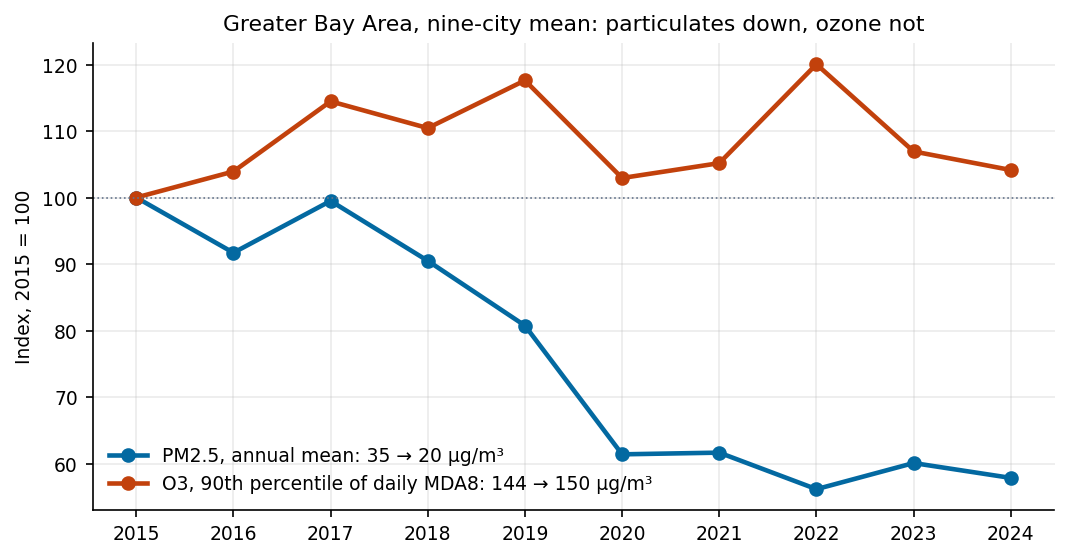

,PM2.5,PM10,NO2,SO2,O3_MDA8_P90,CO_P95
year,,,,,,
2015,34.8,54.6,33.1,13.4,144.0,1.4
2016,31.9,50.0,34.3,11.2,149.6,1.2
2017,34.6,54.0,37.4,10.8,164.8,1.2
2018,31.5,NaN,34.2,9.2,159.0,1.1
2019,28.1,48.2,33.3,7.4,169.4,1.2
2020,21.4,38.4,26.2,7.0,148.2,0.9
2021,21.4,41.3,27.1,7.3,151.4,0.9
2022,19.5,35.2,23.5,6.6,172.9,0.9
2023,20.9,37.7,23.2,6.5,154.0,0.8


In [4]:
display(Image(filename=str(figures.diverging_trends(years))))
analysis.regional(years).set_index("year")

## 4. PM2.5 by city

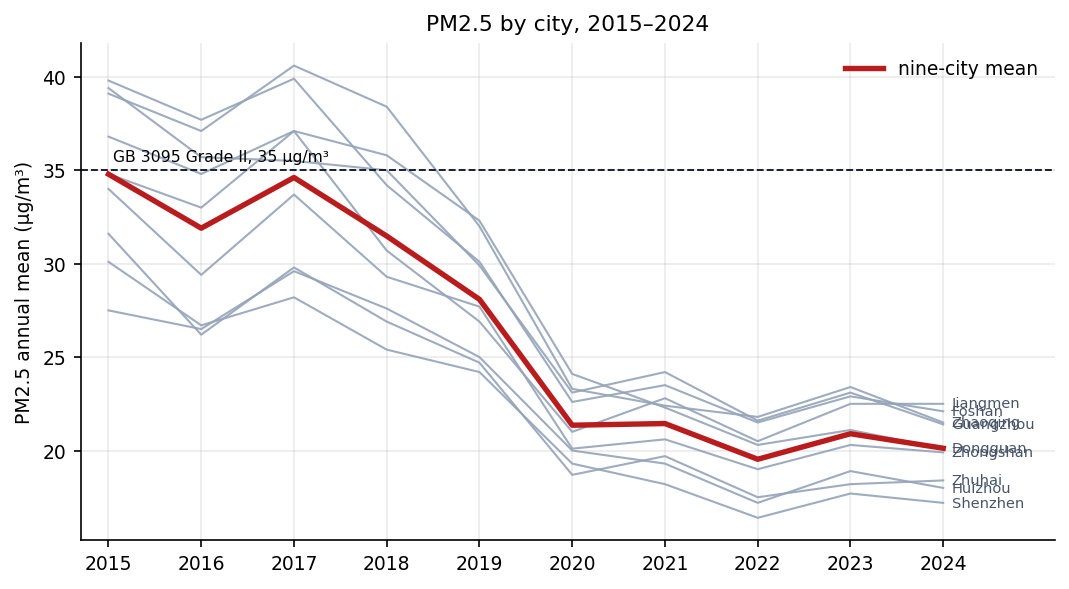

In [5]:
display(Image(filename=str(figures.pm25_by_city(years))))

## 5. Every pollutant, every city: change over the decade

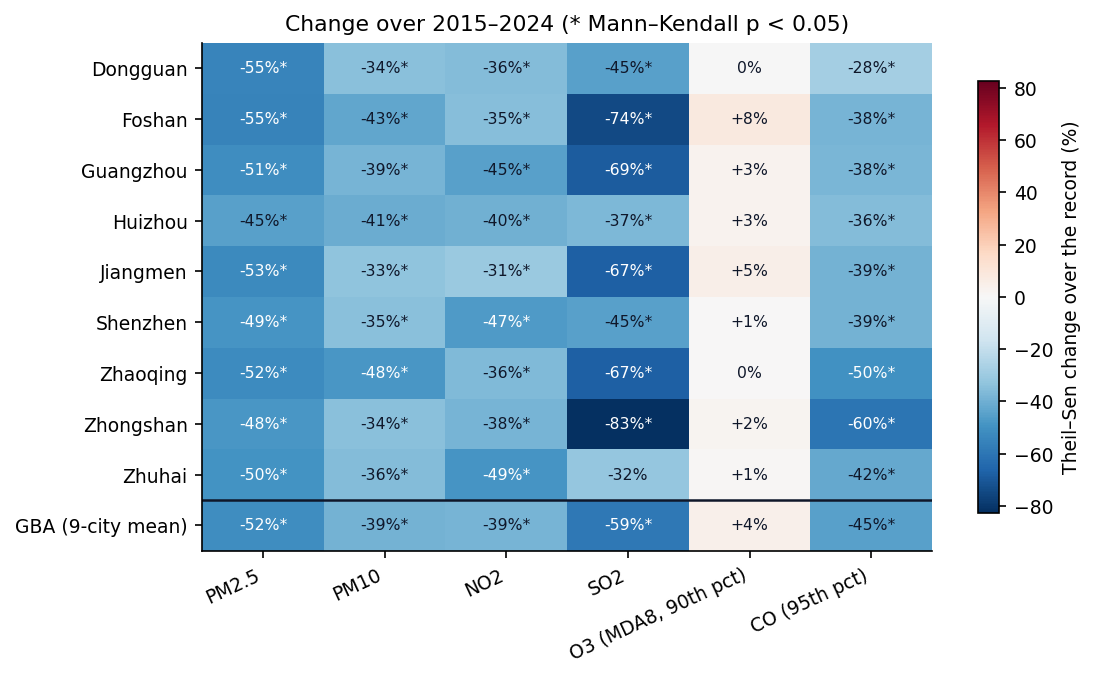

,years,Theil–Sen slope /yr,95% interval,Mann–Kendall p,change over record
pollutant,,,,,
PM2.5,10,-1.91,-2.89 to -0.91,0.0004,-52%
PM10,9,-2.28,-3.18 to -1.59,0.0024,-39%
NO2,10,-1.60,-2.39 to -0.92,0.0022,-39%
SO2,10,-0.68,-1.07 to -0.27,<0.0001,-59%
O3_MDA8_P90,10,+0.66,-2.53 to +3.87,0.4843,+4%
CO_P95,10,-0.06,-0.09 to -0.04,0.0001,-45%


In [6]:
display(Image(filename=str(figures.trend_heatmap(years))))
t = analysis.trends(years)
g = t[t["city"] == "GBA (9-city mean)"].set_index("pollutant")
pd.DataFrame({
    "years": g["n"],
    "Theil–Sen slope /yr": g["slope"].map("{:+.2f}".format),
    "95% interval": [f"{lo:+.2f} to {hi:+.2f}" for lo, hi in zip(g["low"], g["high"])],
    "Mann–Kendall p": g["p"].map(lambda p: "<0.0001" if p < 1e-4 else f"{p:.4f}"),
    "change over record": g["change_pct"].map("{:+.0f}%".format),
})

## 6. Seasonal cycle

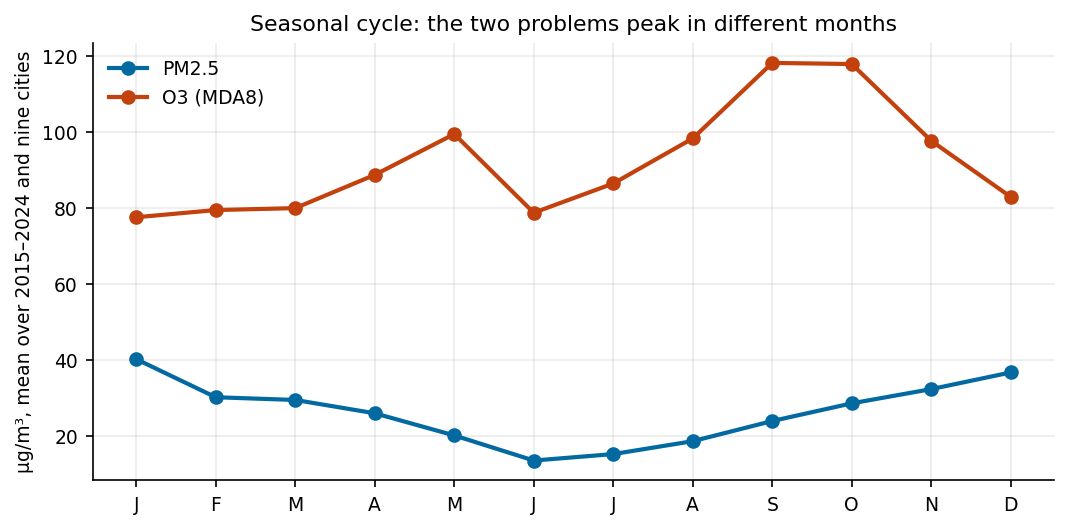

PM2.5 peaks in month 1, ozone (MDA8) in month 9


,PM2.5,O3_MDA8
calendar_month,,
1,40.2,77.5
2,30.1,79.4
3,29.4,79.9
4,25.9,88.7
5,20.1,99.4
6,13.5,78.7
7,15.2,86.4
8,18.6,98.3
9,23.9,118.2


In [7]:
display(Image(filename=str(figures.seasonal_cycle(months))))
cycle = analysis.seasonal_cycle(months)
print(f"PM2.5 peaks in month {cycle['PM2.5'].idxmax()}, ozone (MDA8) in month {cycle['O3_MDA8'].idxmax()}")
cycle[["PM2.5", "O3_MDA8"]]

## 7. The 2020 lockdown, with the Spring Festival held fixed

A calendar-month comparison mixes the lockdown with where the holiday fell, since the
Spring Festival moves by up to three weeks and empties Guangdong's factories every year.
The aligned comparison takes days 8–37 after the festival in each year, so every window
contains the post-holiday period and only 2020's is also the lockdown.

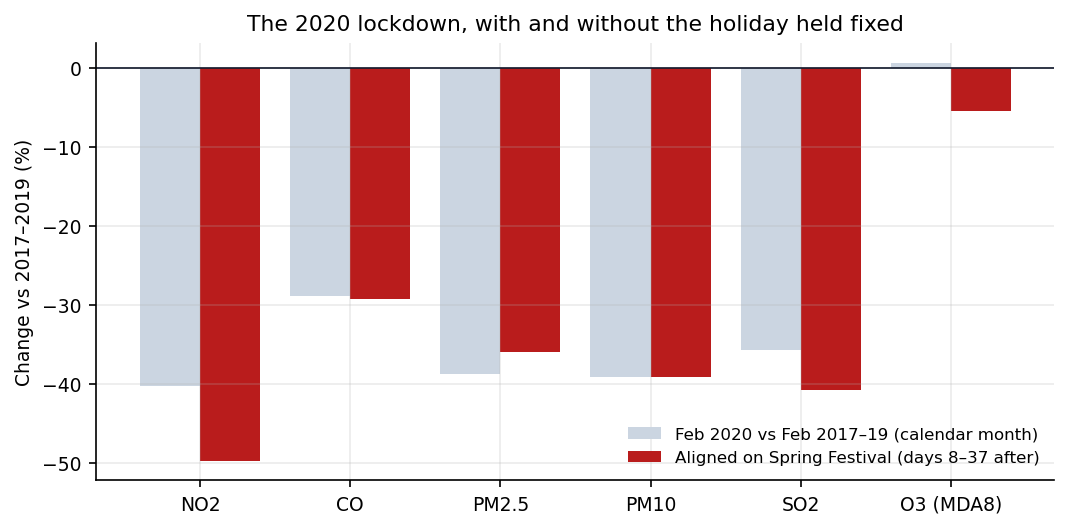

,calendar February,holiday-aligned
PM2.5,-38.7,-35.9
PM10,-39.1,-39.1
SO2,-35.7,-40.8
NO2,-40.3,-49.7
CO,-28.9,-29.2
O3_MDA8,0.6,-5.4


In [8]:
display(Image(filename=str(figures.lockdown(days))))
pd.concat({"calendar February": analysis.lockdown_february(days)["change_pct"],
           "holiday-aligned": analysis.lockdown_holiday_aligned(days)["change_pct"]}, axis=1)

## 8. Which pollutant sets the air quality index

The daily AQI by HJ 633-2012: each pollutant's sub-index from Table 1, rounded up as the
standard requires; the AQI is the largest, and above 50 the pollutant that reaches it is
primary (ties share it). Only city-days with all six pollutants valid are scored.

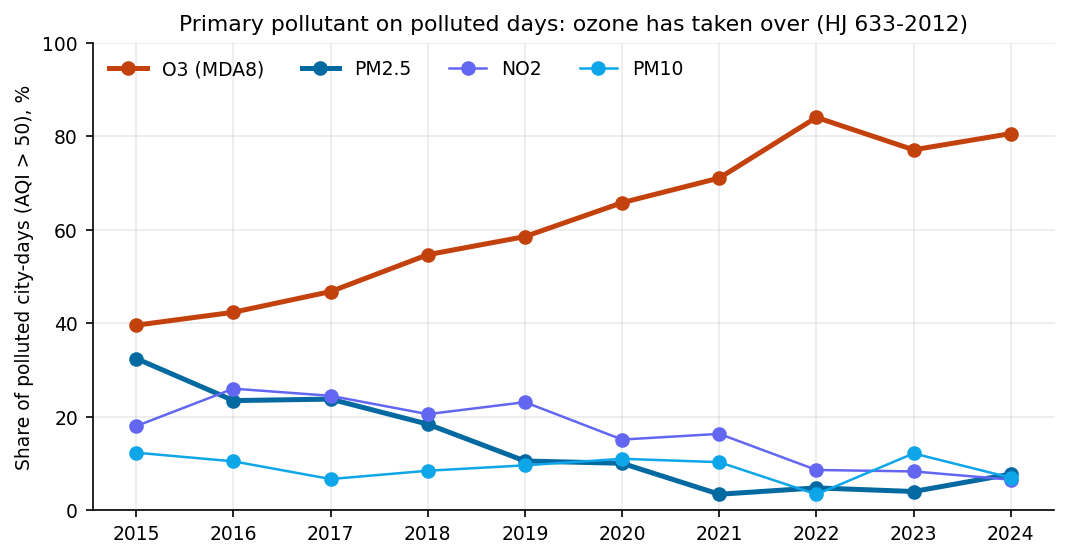

,O3_MDA8,PM2.5,NO2,PM10,polluted_city_days,"O3 MDA8 > 160, % of city-days"
year,,,,,,
2015,39.6,32.5,18.0,12.4,1668,6.1
2016,42.4,23.5,26.0,10.5,1762,7.4
2017,46.8,23.8,24.5,6.7,1982,11.0
2018,54.7,18.5,20.6,8.5,1826,9.9
2019,58.6,10.6,23.2,9.6,1835,12.5
2020,65.8,10.1,15.2,11.0,1458,6.7
2021,71.1,3.5,16.4,10.3,1734,7.9
2022,84.1,4.8,8.7,3.4,1514,13.7
2023,77.2,4.0,8.3,12.2,1558,8.5


In [9]:
display(Image(filename=str(figures.primary_pollutant(days))))
shares = analysis.primary_pollutant_shares(days)
exceed = analysis.ozone_exceedance(days).rename("O3 MDA8 > 160, % of city-days")
shares[["O3_MDA8", "PM2.5", "NO2", "PM10", "polluted_city_days"]].join(exceed).round(1)

## 9. The latest year against the national standard (Grade II)

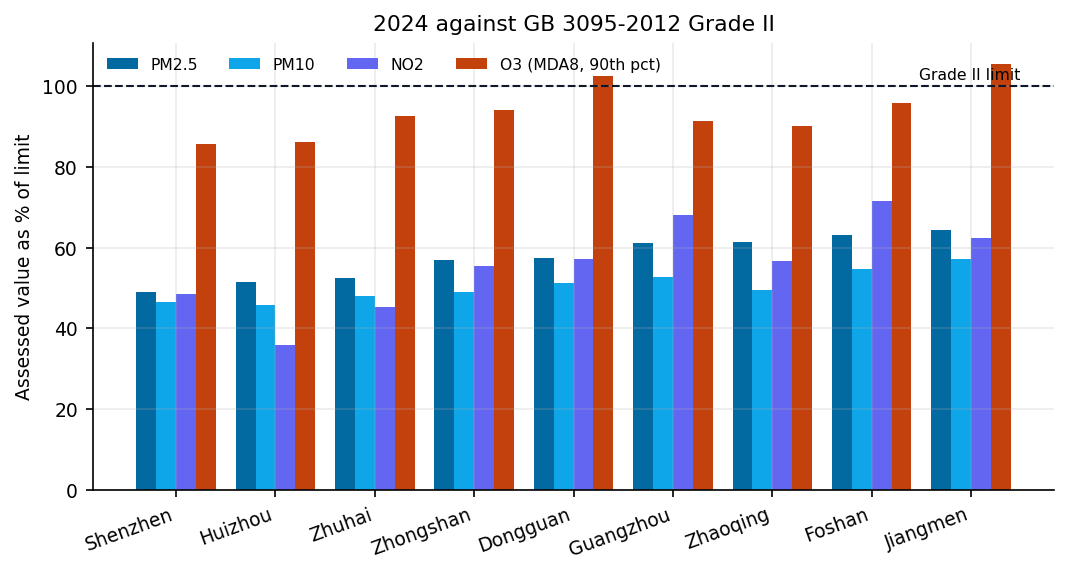

,PM2.5,PM10,SO2,NO2,O3_MDA8_P90,CO_P95
city,,,,,,
Shenzhen,49.0,47.0,9.0,48.0,86.0,18.0
Huizhou,51.0,46.0,10.0,36.0,86.0,19.0
Zhuhai,53.0,48.0,11.0,45.0,92.0,17.0
Zhongshan,57.0,49.0,9.0,56.0,94.0,18.0
Dongguan,57.0,51.0,12.0,57.0,102.0,23.0
Guangzhou,61.0,53.0,10.0,68.0,91.0,22.0
Zhaoqing,61.0,49.0,12.0,57.0,90.0,20.0
Foshan,63.0,55.0,12.0,72.0,96.0,22.0
Jiangmen,64.0,57.0,10.0,62.0,105.0,22.0


In [10]:
display(Image(filename=str(figures.against_standard(years, LATEST))))
analysis.against_standard(years, LATEST).round(0)

## 10. What the numbers say

Generated from the tables above rather than written by hand, so it cannot drift from them.

In [11]:
region = analysis.regional(years).set_index("year").dropna(how="all")
t = analysis.trends(years).set_index(["city", "pollutant"])
g = "GBA (9-city mean)"
lines = []
for p in ["PM2.5", "NO2", "SO2", "O3_MDA8_P90"]:
    r = t.loc[(g, p)]
    sig = "significant" if r["p"] < 0.05 else "not significant"
    lines.append(f"- {analysis.LABEL[p]}: {r['change_pct']:+.0f}% over the record "
                 f"(Theil–Sen {r['slope']:+.2f} {metrics.UNITS[p]}/yr, Mann–Kendall p = {r['p']:.3f}, {sig})")
latest = analysis.against_standard(years, LATEST)
over = latest.columns[(latest > 100).any()].tolist()
lines.append(f"- In {LATEST}, statistics above the Grade II limit in at least one city: "
             + (", ".join(analysis.LABEL[c] for c in over) if over else "none"))
sh = analysis.primary_pollutant_shares(days)
first_y, last_y = int(sh.index.min()), int(sh.index.max())
lines.append(f"- Ozone was the primary pollutant on {sh.loc[first_y, 'O3_MDA8']:.0f}% of polluted city-days in {first_y} "
             f"and {sh.loc[last_y, 'O3_MDA8']:.0f}% in {last_y}; PM2.5 on {sh.loc[first_y, 'PM2.5']:.0f}% and {sh.loc[last_y, 'PM2.5']:.0f}%")
print("\n".join(lines))

- PM2.5: -52% over the record (Theil–Sen -1.91 µg/m³/yr, Mann–Kendall p = 0.000, significant)
- NO2: -39% over the record (Theil–Sen -1.60 µg/m³/yr, Mann–Kendall p = 0.002, significant)
- SO2: -59% over the record (Theil–Sen -0.68 µg/m³/yr, Mann–Kendall p = 0.000, significant)
- O3 (MDA8, 90th pct): +4% over the record (Theil–Sen +0.66 µg/m³/yr, Mann–Kendall p = 0.484, not significant)
- In 2024, statistics above the Grade II limit in at least one city: O3 (MDA8, 90th pct)
- Ozone was the primary pollutant on 40% of polluted city-days in 2015 and 81% in 2024; PM2.5 on 32% and 8%
